In [1]:
import os
os.chdir("..") # Ek folder piche jane ke liye
print(os.getcwd()) # Check karein ke ab path 'psl_ai_platform' par hai ya nahi

c:\Users\User\Desktop\psl_ai_platform


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/processed/ball_by_ball/psl_ball_by_ball_clean.csv")
df.head()

,match_id,innings_number,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,...,fielders_involved,match_date,city,venue,team1,team2,toss_winner,toss_decision,phase,ball_id
0,959175,1,Islamabad United,0,1,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.1
1,959175,1,Islamabad United,0,2,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.2
2,959175,1,Islamabad United,0,3,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.3
3,959175,1,Islamabad United,0,4,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.4
4,959175,1,Islamabad United,0,5,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.5


In [4]:
workload_df = (
    df.groupby(["match_id", "match_date", "bowler"])
    .agg(
        balls_bowled=("bowler", "count"),
        runs_conceded=("runs_total", "sum"),
        wickets_taken=("wicket", "sum"),
    )
    .reset_index()
)

workload_df["overs_bowled"] = (workload_df["balls_bowled"] / 6).round(2)
workload_df["match_date"] = pd.to_datetime(workload_df["match_date"])
workload_df.head()

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled
0,959175,2016-02-04,AD Russell,12,31,0,2.00
1,959175,2016-02-04,Akbar-ur-Rehman,12,8,0,2.00
2,959175,2016-02-04,Anwar Ali,20,21,0,3.33
3,959175,2016-02-04,Imran Khalid,24,20,0,4.00
4,959175,2016-02-04,Mohammad Irfan,18,33,0,3.00


In [5]:
workload_df.shape

(3930, 7)

In [6]:
workload_df.groupby("bowler")["balls_bowled"].sum().sort_values(ascending=False).head(20)

bowler
Hasan Ali              2239
Shadab Khan            2103
Shaheen Shah Afridi    2084
Wahab Riaz             2060
Imad Wasim             2049
Mohammad Amir          2048
Faheem Ashraf          1706
Haris Rauf             1680
Sohail Tanvir          1329
Naseem Shah            1213
Mohammad Irfan         1186
Mohammad Nawaz (3)     1147
Usama Mir              1118
Umaid Asif             1067
Mohammad Wasim         1063
Shahid Afridi          1030
Rumman Raees           1024
Mohammad Hasnain       1004
Sohail Khan             984
Imran Tahir             953
Name: balls_bowled, dtype: int64

In [7]:
bowler_name = "Shaheen Shah Afridi"
shaheen_df = workload_df[workload_df["bowler"] == bowler_name].sort_values("match_date")
shaheen_df

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled
581,1128820,2018-02-23,Shaheen Shah Afridi,20,35,0,3.33
605,1128822,2018-02-24,Shaheen Shah Afridi,14,12,0,2.33
635,1128825,2018-02-26,Shaheen Shah Afridi,19,39,0,3.17
768,1128837,2018-03-09,Shaheen Shah Afridi,22,6,0,3.67
816,1128841,2018-03-11,Shaheen Shah Afridi,25,45,0,4.17
...,...,...,...,...,...,...,...
3684,1527552,2026-03-26,Shaheen Shah Afridi,24,33,0,4.00
3743,1527557,2026-03-29,Shaheen Shah Afridi,26,18,0,4.33
3792,1527562,2026-04-03,Shaheen Shah Afridi,19,32,0,3.17
3854,1527567,2026-04-09,Shaheen Shah Afridi,18,26,0,3.00


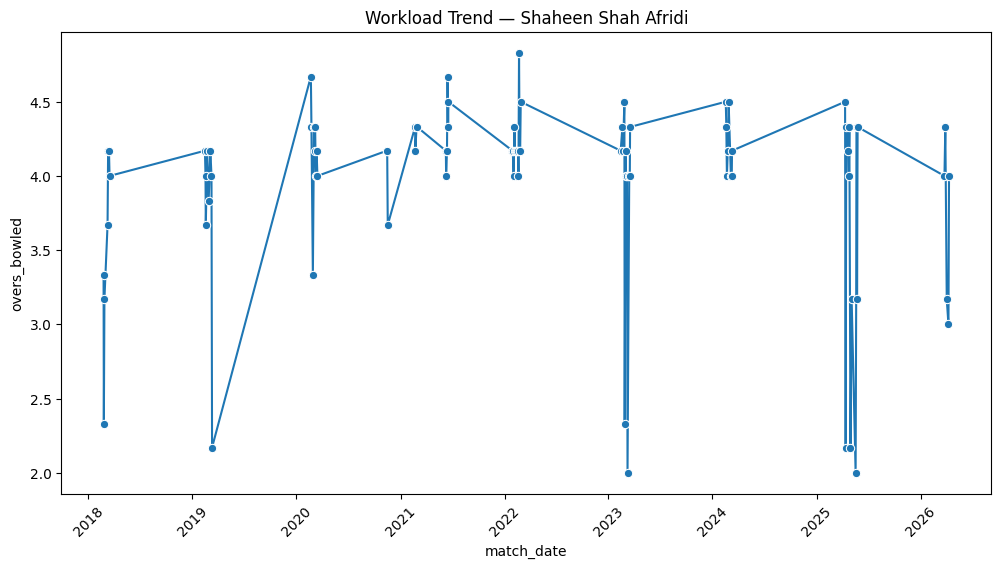

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=shaheen_df, x="match_date", y="overs_bowled", marker="o")
plt.title(f"Workload Trend — {bowler_name}")
plt.xticks(rotation=45)
plt.show()